구글 드라이브를 코랩에 연결하는 코드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint

#경로 설정
base_dir = '/content/drive/MyDrive/dataset_light'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

#이미지 증강 및 전처리 설정
#MobileNetV2는 0~255 픽셀값을 0~1로 바꿔주는 rescale이 필수
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

#Found 48003 images가 뜨는지 확인
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=True
)
validation_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224,224), batch_size=32, class_mode='binary'
)

#모델 설계 (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

#자동 저장
checkpoint_path = '/content/drive/MyDrive/dtect_model_save.h5'
checkpoint = ModelCheckpoint(filepath=checkpoint_path, save_best_only=True, verbose=1)

#학습 시작
print("\n학습 시작")
model.fit(train_generator, epochs=5, validation_data=validation_generator, callbacks=[checkpoint])

Found 48003 images belonging to 2 classes.
Found 12003 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

학습 시작


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6455 - loss: 0.6164
Epoch 1: val_loss improved from inf to 0.45990, saving model to /content/drive/MyDrive/dtect_model_save.h5


1501/1501 ━━━━━━━━━━━━━━━━━━━━ 357s 223ms/step - accuracy: 0.6456 - loss: 0.6163 - val_accuracy: 0.7770 - val_loss: 0.4599
Epoch 2/5
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7728 - loss: 0.4572
Epoch 2: val_loss improved from 0.45990 to 0.40962, saving model to /content/drive/MyDrive/dtect_model_save.h5


1501/1501 ━━━━━━━━━━━━━━━━━━━━ 242s 161ms/step - accuracy: 0.7728 - loss: 0.4572 - val_accuracy: 0.8055 - val_loss: 0.4096
Epoch 3/5
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7936 - loss: 0.4186
Epoch 3: val_loss improved from 0.40962 to 0.38779, saving model to /content/drive/MyDrive/dtect_model_save.h5


1501/1501 ━━━━━━━━━━━━━━━━━━━━ 240s 160ms/step - accuracy: 0.7936 - loss: 0.4186 - val_accuracy: 0.8168 - val_loss: 0.3878
Epoch 4/5
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8056 - loss: 0.3994
Epoch 4: val_loss improved from 0.38779 to 0.37402, saving model to /content/drive/MyDrive/dtect_model_save.h5


1501/1501 ━━━━━━━━━━━━━━━━━━━━ 241s 161ms/step - accuracy: 0.8056 - loss: 0.3994 - val_accuracy: 0.8258 - val_loss: 0.3740
Epoch 5/5
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8124 - loss: 0.3911
Epoch 5: val_loss improved from 0.37402 to 0.36471, saving model to /content/drive/MyDrive/dtect_model_save.h5


1501/1501 ━━━━━━━━━━━━━━━━━━━━ 234s 156ms/step - accuracy: 0.8124 - loss: 0.3911 - val_accuracy: 0.8310 - val_loss: 0.3647


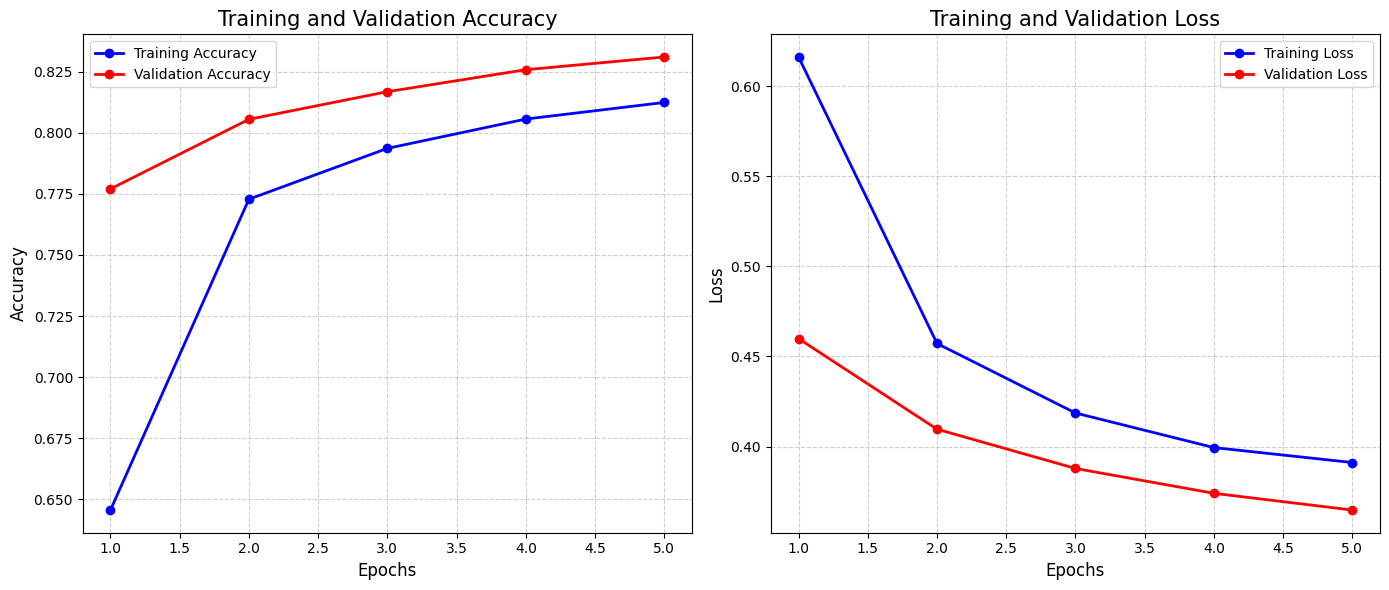

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]
accuracy = [0.6456, 0.7728, 0.7936, 0.8056, 0.8124]
loss = [0.6163, 0.4572, 0.4186, 0.3994, 0.3911]
val_accuracy = [0.7770, 0.8055, 0.8168, 0.8258, 0.8310]
val_loss = [0.4599, 0.4096, 0.3878, 0.3740, 0.3647]

#그래프 설정
plt.figure(figsize=(14, 6))

#정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_accuracy, 'r-o', label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#손실 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 그래프를 이미지 파일로 저장하고 싶으시면 아래 주석을 해제하세요.
plt.savefig('dtect_learning_graph.png')

tflite 추출

In [ ]:
import tensorflow as tf

#저장된 .h5 모델 불러오기
model = tf.keras.models.load_model('/content/drive/MyDrive/dtect_model_save.h5')

#안드로이드용 TFLite 모델로 변환
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

#구글 드라이브에 저장
with open('/content/drive/MyDrive/dtect_model.tflite', 'wb') as f:
  f.write(tflite_model)

print(".tflite 파일 생성")

Saved artifact at '/tmp/tmp2wos60p8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134218441533840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441535952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441534992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441535184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441536528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441535376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441536144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441536336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441534800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134218441537488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1342184415369